In [54]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict

In [55]:
# 많은 state를 관리하게 될텐데,,,사용자가 접근할 수 없게 하고 싶을 수 있음..
class PrivateState(TypedDict):
    a: int
    b: int
    # 야ㅕ기에 넣는다해도 실제로 state에 추가하는거 아님.. 이게 내 staste에 들어갈거야~하고 말하는것뿐...
    # sate에 있는 얘들이 아니면 뭘 넣어도 무시될거야

class InputState(TypedDict):
    hello: str

class OutputState(TypedDict):
    bye: str

class MegaPrivate(TypedDict):
    secret:bool

graph_builder = StateGraph(PrivateState, input_schema=InputState, output_schema=OutputState)

In [56]:
def node_one(state:InputState) -> InputState:
    print("node_one => ",state)
    return {
        "hello":"World"
    }

def node_two(state:PrivateState) -> PrivateState:
    print("two -> ",state)
    return {
        "a" : 1
    }

def node_three(state:PrivateState) -> PrivateState:
    print("three -> ",state)
    return {
        "b":1
    }

def node_four(state:PrivateState) -> OutputState:
    print("four=> ",state)
    return {
        "bye" : "world"
    }

def node_five(state:OutputState):
    return{
        "secret":True
    }

def node_six(state:MegaPrivate):
    print(state)

In [57]:
graph_builder.add_node("node_one", node_one)
graph_builder.add_node("node_two", node_two)
graph_builder.add_node("node_three", node_three)
graph_builder.add_node("node_four", node_four)
graph_builder.add_node("node_five", node_five)
graph_builder.add_node("node_six", node_six)

# 연결
graph_builder.add_edge(START,"node_one")
graph_builder.add_edge("node_one", "node_two")
graph_builder.add_edge("node_two", "node_three")
graph_builder.add_edge("node_three", "node_four")
graph_builder.add_edge("node_four", "node_five")
graph_builder.add_edge("node_five", "node_six")
graph_builder.add_edge("node_six", END)

In [58]:
# 그래프 컴파일
# 그래프랑 edge들이 다~말이되는지화긘 (유효성검사)
graph = graph_builder.compile()
result = graph.invoke({
    'hello':'world'
})


node_one =>  {'hello': 'world'}
two ->  {}
three ->  {'a': 1}
four=>  {'a': 1, 'b': 1}
{'secret': True}


In [59]:
result

{'bye': 'world'}

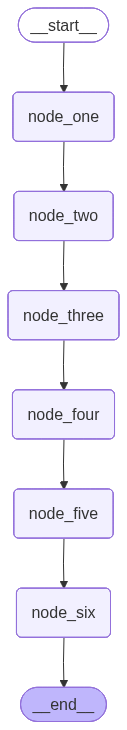

In [60]:
graph
# 위에 api가 먹통되는 경우가 있음. 그럴때 아래꺼로 실행해서 볼수이씅ㅁ.
#  print(graph.get_graph().draw_ascii()) 